# 1.Przygotowanie danych

## Dlaczego standaryzacja przed PCA jest konieczna?
PCA szuka kierunków o największej wariancji, innymi słowy o największym rozrzucie danych. Jeśli cechy mają różne skale, to PCA zostanie oślepione przez cechę o największych wartoścach liczbowych. W zbiorze Wine mamy przykładowo *Proline* (wartości rzędu 1000) i *Nonflavanoid phenols* (wartości rzędu 0.2). Bez standaryzacji PCA uznałoby, że *Proline* to najważniejsza cecha na świecie tym samym całkowicie ignorując te o małych wartościach. Standaryzacja (średnia 0, odchylenie 1) zrównuje siłę głosu każdej cechy.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Ustawienia wykresów
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 14

print("1. Przygotowanie danych")
# 1.1 Załaduj zbiór danych Wine
wine = load_wine()
X = wine.data
y = wine.target
nazwy_cech = wine.feature_names
nazwy_klas = wine.target_names

# 1.2 Wyświetl statystyki
print(f"Liczba próbek: {X.shape[0]}")
print(f"Liczba cech: {X.shape[1]}")
print(f"Klasy (gatunki wina): {nazwy_klas}")
unique, counts = np.unique(y, return_counts=True)
print(f"Rozkład klas: {dict(zip(nazwy_klas, counts))}")

# 1.3 Standaryzacja
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

print("\nŚrednie przed standaryzacją (pierwsze 3 cechy):", X[:, :3].mean(axis=0).round(2))
print("Średnie po standaryzacji (pierwsze 3 cechy):", X_std[:, :3].mean(axis=0).round(2))

1. Przygotowanie danych
Liczba próbek: 178
Liczba cech: 13
Klasy (gatunki wina): ['class_0' 'class_1' 'class_2']
Rozkład klas: {np.str_('class_0'): np.int64(59), np.str_('class_1'): np.int64(71), np.str_('class_2'): np.int64(48)}

Średnie przed standaryzacją (pierwsze 3 cechy): [13.    2.34  2.37]
Średnie po standaryzacji (pierwsze 3 cechy): [ 0.  0. -0.]


# 2. Wykonanie PCA
## Ile składowych potrzeba dla ≥ 80% wariancji?
Aby przekroczyć próg 80% wyjaśnionej wariancji w zbiorze Wine, potrzebujemy 5 składowych (PC1 do PC5). Tłumaczą one łącznie około 80.2% całkowitej informacji zawartej w danych.

In [6]:
print("2. Wykonanie PCA")

# 2.1 PCA na wszystkich składowych
pca = PCA()
X_pca = pca.fit_transform(X_std)

# 2.2 Wyświetl wyniki
print("\nWartości własne (eigenvalues):")
for i, ev in enumerate(pca.explained_variance_):
    print(f" PC{i+1}: {ev:.3f}")

print("\nWyjaśniona wariancja (%):")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f" PC{i+1}: {var*100:.1f}%")

print("\nSkumulowana wariancja:")
cumsum = np.cumsum(pca.explained_variance_ratio_)
for i, cs in enumerate(cumsum):
    print(f" PC1-PC{i+1}: {cs*100:.1f}%")

# 2.3 Automatyczne znalezienie progu 80%
ile_składowych_80 = np.argmax(cumsum >= 0.80) + 1
print(f"\n→ Aby uzyskać >= 80% wariancji, potrzeba: {ile_składowych_80} składowych.")

2. Wykonanie PCA

Wartości własne (eigenvalues):
 PC1: 4.732
 PC2: 2.511
 PC3: 1.454
 PC4: 0.924
 PC5: 0.858
 PC6: 0.645
 PC7: 0.554
 PC8: 0.350
 PC9: 0.291
 PC10: 0.252
 PC11: 0.227
 PC12: 0.170
 PC13: 0.104

Wyjaśniona wariancja (%):
 PC1: 36.2%
 PC2: 19.2%
 PC3: 11.1%
 PC4: 7.1%
 PC5: 6.6%
 PC6: 4.9%
 PC7: 4.2%
 PC8: 2.7%
 PC9: 2.2%
 PC10: 1.9%
 PC11: 1.7%
 PC12: 1.3%
 PC13: 0.8%

Skumulowana wariancja:
 PC1-PC1: 36.2%
 PC1-PC2: 55.4%
 PC1-PC3: 66.5%
 PC1-PC4: 73.6%
 PC1-PC5: 80.2%
 PC1-PC6: 85.1%
 PC1-PC7: 89.3%
 PC1-PC8: 92.0%
 PC1-PC9: 94.2%
 PC1-PC10: 96.2%
 PC1-PC11: 97.9%
 PC1-PC12: 99.2%
 PC1-PC13: 100.0%

→ Aby uzyskać >= 80% wariancji, potrzeba: 5 składowych.


# 3. Wizualizacja


3. Wizualizacje


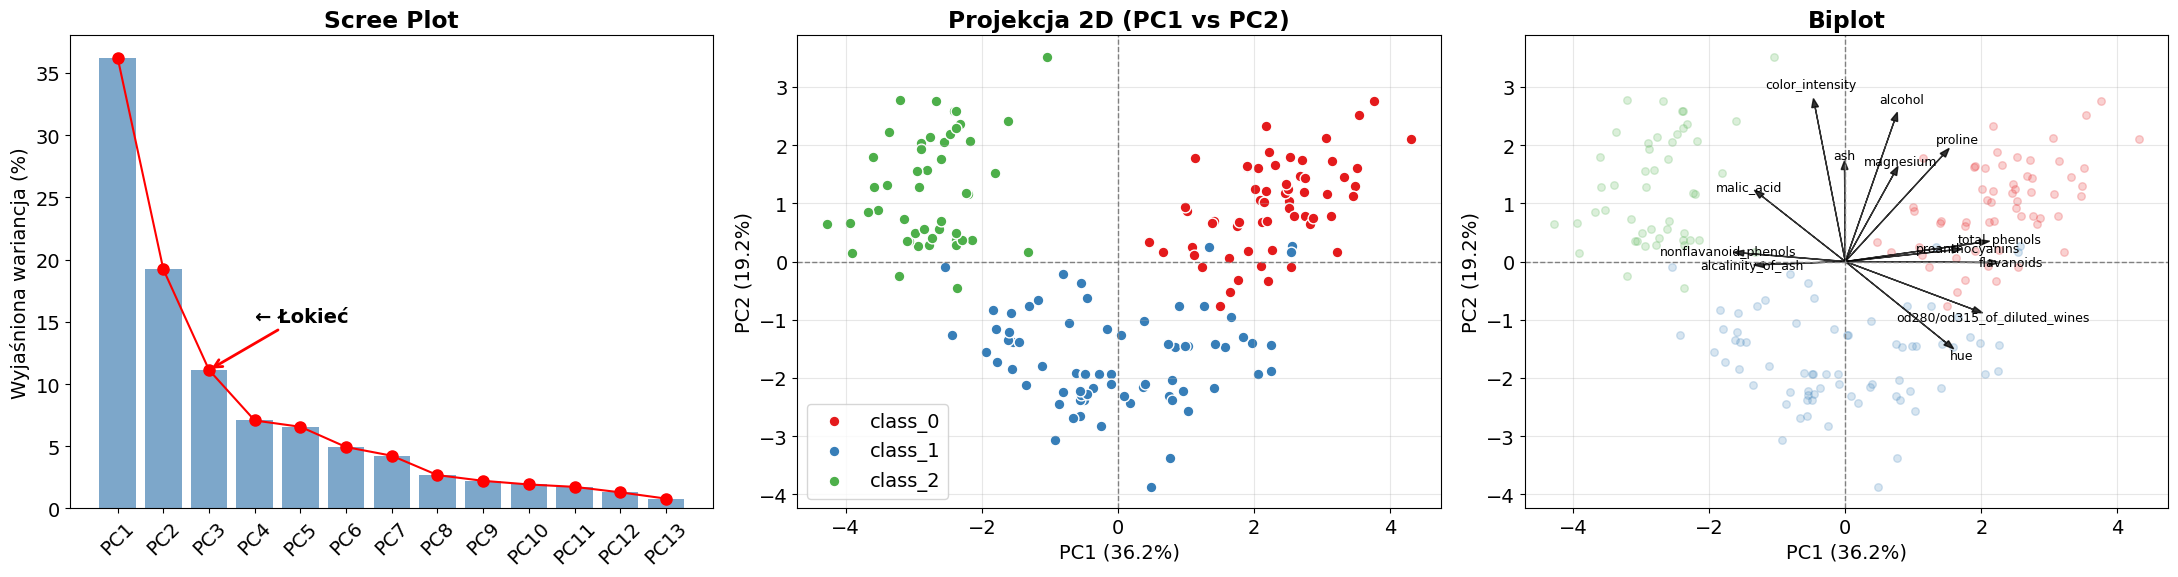

In [7]:
print("3. Wizualizacje")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

pc_labels = [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))]
variance_pct = pca.explained_variance_ratio_ * 100
cumulative = np.cumsum(variance_pct)

# 3.1 Scree Plot (Wykres osypiska)
ax1 = axes[0]
ax1.bar(pc_labels, variance_pct, color='steelblue', alpha=0.7)
ax1.plot(pc_labels, variance_pct, 'ro-', markersize=8)
ax1.set_title('Scree Plot', fontweight='bold')
ax1.set_ylabel('Wyjaśniona wariancja (%)')
ax1.tick_params(axis='x', rotation=45)
# Ręcznie oznaczony łokieć (najostrzejsze zagięcie na PC3)
ax1.annotate('← Łokieć', xy=(2, variance_pct[2]), xytext=(3, 15),
             arrowprops=dict(arrowstyle='->', color='red', lw=2), fontweight='bold')

# 3.2 Projekcja 2D (PC1 vs PC2)
ax2 = axes[1]
colors = ['#e41a1c', '#377eb8', '#4daf4a']
for i, (klasa, kolor) in enumerate(zip(nazwy_klas, colors)):
    mask = y == i
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1], c=kolor, label=klasa, s=60, edgecolor='white')

ax2.set_xlabel(f'PC1 ({variance_pct[0]:.1f}%)')
ax2.set_ylabel(f'PC2 ({variance_pct[1]:.1f}%)')
ax2.set_title('Projekcja 2D (PC1 vs PC2)', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.axhline(0, color='gray', linestyle='--', lw=1)
ax2.axvline(0, color='gray', linestyle='--', lw=1)

# 3.3 Biplot
ax3 = axes[2]
# Rysujemy punkty w tle na blado
for i, (klasa, kolor) in enumerate(zip(nazwy_klas, colors)):
    mask = y == i
    ax3.scatter(X_pca[mask, 0], X_pca[mask, 1], c=kolor, s=30, alpha=0.2)

scale = 5 # Skalowanie dla czytelności wektorów
for i, nazwa in enumerate(nazwy_cech):
    x_vec = pca.components_[0, i] * scale
    y_vec = pca.components_[1, i] * scale
    ax3.arrow(0, 0, x_vec, y_vec, head_width=0.1, color='black', alpha=0.8)
    ax3.text(x_vec * 1.15, y_vec * 1.15, nazwa, fontsize=9, ha='center', va='center')

ax3.set_xlabel(f'PC1 ({variance_pct[0]:.1f}%)')
ax3.set_ylabel(f'PC2 ({variance_pct[1]:.1f}%)')
ax3.set_title('Biplot', fontweight='bold')
ax3.grid(alpha=0.3)
ax3.axhline(0, color='gray', linestyle='--', lw=1)
ax3.axvline(0, color='gray', linestyle='--', lw=1)

plt.tight_layout()
plt.show()

# 4.Interpretacja
## 4.2 Odpowiedzi do analizy


*   **Co dominuje w PC1?**

    Składowa w PC1 jest zdominowana (największe wartości bezwzględne ładunków) przez zawartość fenoli (Flavanoids, Total pheneols) oraz OD280/OD315 (stosunek absorbancji). Wartości są ujemne albo mocno dodatnie. PC1 reprezentuje generalnie fenolowy profil oraz jakość wina.

*   **Co dominuje w PC2?**

    Składowa PC2 jest mocno napędzana przez *Color intensity* oraz zawartość *Alcohol* i w ujemnym stopniu *Hue*. Reprezentuje ona zatem siłę barwy i moc alkoholu wina.

*   **Czy klasy są dobrze separowalne w 2D?**

    Tak. Jak widać na wykresie "Projekcja 2D", chmury punktów reprezentujące poszczególne szczepy wina (class_0, class_1, class_2) grupują się w bardzo wyraźnych, oddzielonych od siebie klastrach. PC1 i PC2 świetnie radzą sobie z rozróżnianiem gatunków mimo reduckji z 13 do 2 wymiarów.

*   **Różnica bez standaryzacji, która cecha by zdominowała?**

    Gdybyśmy nie zastosowali standaryzacji, analizę zdominowałaby cecha Proline, Jej wartości sięgają prawie 1700


In [8]:
print("4. Interpretacja (Ładunki")

# Pokazujemy ładunki (loadings) dla PC1 i PC2
loadings_df = pd.DataFrame(
    pca.components_[:2, :].T,
    columns=['PC1', 'PC2'],
    index=nazwy_cech
)

# Wyświetlamy ładunki posortowane absolutnie dla PC1
print("\nŁadunki (wpływ cech) dla PC1 (posortowane po sile wpływu):")
print(loadings_df['PC1'].abs().sort_values(ascending=False).round(3))

print("\nŁadunki (wpływ cech) dla PC2 (posortowane po sile wpływu):")
print(loadings_df['PC2'].abs().sort_values(ascending=False).round(3))

4. Interpretacja (Ładunki

Ładunki (wpływ cech) dla PC1 (posortowane po sile wpływu):
flavanoids                      0.423
total_phenols                   0.395
od280/od315_of_diluted_wines    0.376
proanthocyanins                 0.313
nonflavanoid_phenols            0.299
hue                             0.297
proline                         0.287
malic_acid                      0.245
alcalinity_of_ash               0.239
alcohol                         0.144
magnesium                       0.142
color_intensity                 0.089
ash                             0.002
Name: PC1, dtype: float64

Ładunki (wpływ cech) dla PC2 (posortowane po sile wpływu):
color_intensity                 0.530
alcohol                         0.484
proline                         0.365
ash                             0.316
magnesium                       0.300
hue                             0.279
malic_acid                      0.225
od280/od315_of_diluted_wines    0.164
total_phenols                 